## Modeling — Binary At-Risk (SMOTE + Bayesian Optimization, F1 At-Risk)

Gộp **Fail** và **Withdrawn** thành một lớp duy nhất: **At-risk**. Lớp còn lại là **Pass**.

Mỗi `prediction_point` train một model riêng:
1. **SMOTE** — oversample At-risk, tỷ lệ tăng `(1 + x) * N_current` với `x ∈ [0.1, 0.9]`
2. **Bayesian Optimization** — tìm đồng thời: hyperparameter mô hình + SMOTE ratio + class weight cho At-risk
3. **Metric**: F1-score của At-risk (đổi từ recall thuần vì recall-only khiến model dự đoán toàn bộ về At-risk)
4. **Evaluate** — test với `predict()` thông thường, không threshold tuning

In [5]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path().resolve().parent))
from config import RANDOM_SEED, SNAPSHOTS

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from imblearn.over_sampling import SMOTE
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    recall_score, precision_score, accuracy_score, f1_score,
)

In [6]:
data_dir = Path('../data/processed')

X_train    = pd.read_parquet(data_dir / 'X_train.parquet')
X_test     = pd.read_parquet(data_dir / 'X_test.parquet')
y_train    = pd.read_parquet(data_dir / 'y_train.parquet').squeeze()
y_test     = pd.read_parquet(data_dir / 'y_test.parquet').squeeze()
train_meta = pd.read_parquet(data_dir / 'train_meta.parquet')
test_meta  = pd.read_parquet(data_dir / 'test_meta.parquet')

# Gộp Fail (0) và Withdrawn (2) thành At-risk (1); Pass (1) -> 0
LABEL_MAP = {0: 1, 1: 0, 2: 1}
y_train = y_train.map(LABEL_MAP)
y_test  = y_test.map(LABEL_MAP)

TARGET_NAMES = ['Pass', 'At-risk']

print('X_train:', X_train.shape)
print('Features:', list(X_train.columns))
print('Snapshots:', sorted(train_meta['prediction_point'].unique()))
print('Phân phối nhãn (train):', y_train.value_counts().to_dict())

X_train: (142384, 15)
Features: ['highest_education', 'disability', 'num_of_prev_attempts', 'studied_credits', 'total_clicks_filled', 'active_weeks_filled', 'avg_weekly_clicks_filled', 'num_due', 'num_submitted_filled', 'avg_score_filled', 'num_failed_filled', 'avg_days_early_filled', 'no_submission_despite_due', 'imd_band_filled', 'imd_missing']
Snapshots: [np.int64(30), np.int64(60), np.int64(90), np.int64(120), np.int64(150), np.int64(180), np.int64(210), np.int64(240)]
Phân phối nhãn (train): {0: 88536, 1: 53848}


### Helper functions

In [7]:
def get_snapshot_data(T):
    mask_tr = train_meta['prediction_point'].values == T
    mask_te = test_meta['prediction_point'].values == T
    return (
        X_train[mask_tr].reset_index(drop=True),
        X_test[mask_te].reset_index(drop=True),
        y_train[mask_tr].reset_index(drop=True),
        y_test[mask_te].reset_index(drop=True),
    )


def safe_smote(X, y, ratio_at_risk=0.5):
    """new_count = int((1 + ratio) * N_current),  ratio in [0.1, 0.9]"""
    y_s = pd.Series(y)
    n_at_risk = (y_s == 1).sum()
    n_pass    = (y_s == 0).sum()
    target = {1: int((1 + ratio_at_risk) * n_at_risk)}
    k = max(1, min(5, n_at_risk - 1, n_pass - 1))
    smote = SMOTE(sampling_strategy=target, random_state=RANDOM_SEED, k_neighbors=k)
    cols = X.columns.tolist() if hasattr(X, 'columns') else None
    X_res, y_res = smote.fit_resample(np.array(X), np.array(y))
    return pd.DataFrame(X_res, columns=cols), pd.Series(y_res)


def evaluate_full(name, y_true, y_pred):
    sep = '=' * 55
    print(f'\n{sep}\n  {name}\n{sep}')
    print(classification_report(y_true, y_pred, target_names=TARGET_NAMES, digits=3))
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(4, 3))
    ConfusionMatrixDisplay(cm, display_labels=TARGET_NAMES).plot(ax=ax, colorbar=False)
    ax.set_title(name)
    plt.tight_layout()
    plt.show()

---

## Vòng lặp — tất cả prediction_point

**Ước tính runtime:** ~1-2 giờ (8 mốc x 30 trials x 3 folds + 1 lần retrain mỗi mốc)

**Optuna tìm đồng thời:**
- Hyperparameter mô hình (max_iter, learning_rate, max_depth, ...)
- SMOTE ratio cho At-risk (`smote_ratio_at_risk` trong [0.1, 0.9])
- Class weight cho At-risk (`w_at_risk` trong [1, 8])

**Lưu ý:** ban đầu tối ưu thuần recall At-risk khiến model dự đoán toàn bộ là At-risk (recall=1 nhưng precision rất thấp). Đã đổi metric tối ưu sang **F1-score At-risk** để cân bằng precision/recall.


############################################################
  PREDICTION POINT = 30 days
############################################################
Train: 19,988 | Test: 5,043


  0%|          | 0/30 [00:00<?, ?it/s]

Best F1 At-risk CV: 0.6935
SMOTE  -> At-risk: +0.12x
Weight -> At-risk: 1.76

  T=30
              precision    recall  f1-score   support

        Pass      0.771     0.632     0.694      2804
     At-risk      0.624     0.765     0.687      2239

    accuracy                          0.691      5043
   macro avg      0.697     0.698     0.691      5043
weighted avg      0.705     0.691     0.691      5043



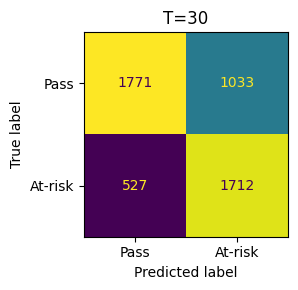


############################################################
  PREDICTION POINT = 60 days
############################################################
Train: 19,123 | Test: 4,835


  0%|          | 0/30 [00:00<?, ?it/s]

Best F1 At-risk CV: 0.7158
SMOTE  -> At-risk: +0.10x
Weight -> At-risk: 1.62

  T=60
              precision    recall  f1-score   support

        Pass      0.797     0.743     0.769      2804
     At-risk      0.675     0.738     0.705      2031

    accuracy                          0.741      4835
   macro avg      0.736     0.740     0.737      4835
weighted avg      0.746     0.741     0.742      4835



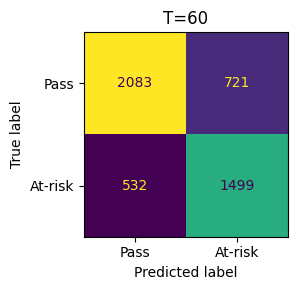


############################################################
  PREDICTION POINT = 90 days
############################################################
Train: 18,508 | Test: 4,680


  0%|          | 0/30 [00:00<?, ?it/s]

Best F1 At-risk CV: 0.7278
SMOTE  -> At-risk: +0.10x
Weight -> At-risk: 1.50

  T=90
              precision    recall  f1-score   support

        Pass      0.815     0.802     0.809      2804
     At-risk      0.711     0.728     0.719      1876

    accuracy                          0.772      4680
   macro avg      0.763     0.765     0.764      4680
weighted avg      0.773     0.772     0.773      4680



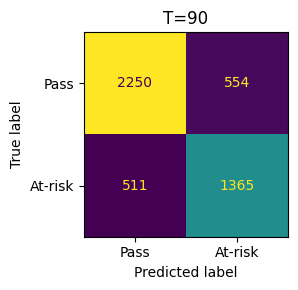


############################################################
  PREDICTION POINT = 120 days
############################################################
Train: 17,917 | Test: 4,518


  0%|          | 0/30 [00:00<?, ?it/s]

Best F1 At-risk CV: 0.7579
SMOTE  -> At-risk: +0.18x
Weight -> At-risk: 1.69

  T=120
              precision    recall  f1-score   support

        Pass      0.855     0.824     0.839      2804
     At-risk      0.728     0.771     0.749      1714

    accuracy                          0.804      4518
   macro avg      0.792     0.798     0.794      4518
weighted avg      0.807     0.804     0.805      4518



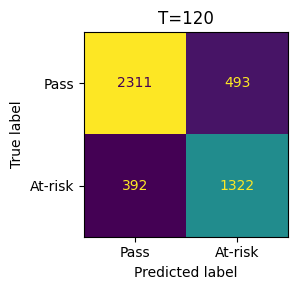


############################################################
  PREDICTION POINT = 150 days
############################################################
Train: 17,386 | Test: 4,363


  0%|          | 0/30 [00:00<?, ?it/s]

Best F1 At-risk CV: 0.7896
SMOTE  -> At-risk: +0.41x
Weight -> At-risk: 1.53

  T=150
              precision    recall  f1-score   support

        Pass      0.878     0.884     0.881      2804
     At-risk      0.789     0.778     0.784      1559

    accuracy                          0.846      4363
   macro avg      0.833     0.831     0.832      4363
weighted avg      0.846     0.846     0.846      4363



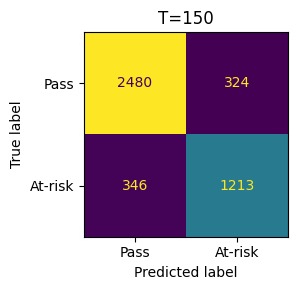


############################################################
  PREDICTION POINT = 180 days
############################################################
Train: 16,786 | Test: 4,215


  0%|          | 0/30 [00:00<?, ?it/s]

Best F1 At-risk CV: 0.8062
SMOTE  -> At-risk: +0.30x
Weight -> At-risk: 1.67

  T=180
              precision    recall  f1-score   support

        Pass      0.903     0.886     0.894      2804
     At-risk      0.781     0.810     0.795      1411

    accuracy                          0.860      4215
   macro avg      0.842     0.848     0.845      4215
weighted avg      0.862     0.860     0.861      4215



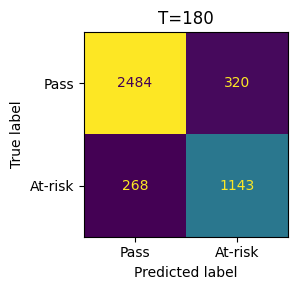


############################################################
  PREDICTION POINT = 210 days
############################################################
Train: 16,486 | Test: 4,162


  0%|          | 0/30 [00:00<?, ?it/s]

Best F1 At-risk CV: 0.8161
SMOTE  -> At-risk: +0.54x
Weight -> At-risk: 1.01

  T=210
              precision    recall  f1-score   support

        Pass      0.892     0.937     0.914      2804
     At-risk      0.854     0.767     0.808      1358

    accuracy                          0.881      4162
   macro avg      0.873     0.852     0.861      4162
weighted avg      0.880     0.881     0.879      4162



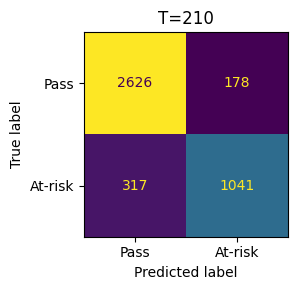


############################################################
  PREDICTION POINT = 240 days
############################################################
Train: 16,190 | Test: 4,094


  0%|          | 0/30 [00:00<?, ?it/s]

Best F1 At-risk CV: 0.8331
SMOTE  -> At-risk: +0.53x
Weight -> At-risk: 1.01

  T=240
              precision    recall  f1-score   support

        Pass      0.905     0.953     0.929      2804
     At-risk      0.885     0.784     0.831      1290

    accuracy                          0.900      4094
   macro avg      0.895     0.869     0.880      4094
weighted avg      0.899     0.900     0.898      4094



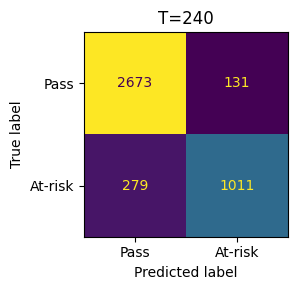


--- Tổng hợp ---


,prediction_point,accuracy,recall_pass,recall_at_risk,precision_pass,precision_at_risk,f1_at_risk
0,30,0.6907,0.6316,0.7646,0.7707,0.6237,0.6870
1,60,0.7408,0.7429,0.7381,0.7966,0.6752,0.7052
2,90,0.7724,0.8024,0.7276,0.8149,0.7113,0.7194
3,120,0.8041,0.8242,0.7713,0.8550,0.7284,0.7492
4,150,0.8464,0.8845,0.7781,0.8776,0.7892,0.7836
5,180,0.8605,0.8859,0.8101,0.9026,0.7813,0.7954
6,210,0.8811,0.9365,0.7666,0.8923,0.8540,0.8079
7,240,0.8999,0.9533,0.7837,0.9055,0.8853,0.8314


In [8]:
models  = {}
results = []

for T in SNAPSHOTS:
    print(f'\n{"#"*60}\n  PREDICTION POINT = {T} days\n{"#"*60}')

    X_tr_raw, X_te_raw, y_tr, y_te = get_snapshot_data(T)
    X_tr = X_tr_raw.fillna(0)
    X_te = X_te_raw.fillna(0)
    print(f'Train: {len(X_tr):,} | Test: {len(X_te):,}')

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_SEED)

    def objective(trial):
        params = {
            'max_iter':          trial.suggest_int('max_iter', 100, 500),
            'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'max_depth':         trial.suggest_int('max_depth', 3, 10),
            'min_samples_leaf':  trial.suggest_int('min_samples_leaf', 10, 100),
            'l2_regularization': trial.suggest_float('l2_regularization', 1e-4, 10.0, log=True),
            'max_leaf_nodes':    trial.suggest_int('max_leaf_nodes', 15, 63),
            'random_state':      RANDOM_SEED,
        }
        r_at_risk = trial.suggest_float('smote_ratio_at_risk', 0.1, 0.9)
        w_at_risk = trial.suggest_float('w_at_risk', 1.0, 8.0)

        fold_scores = []
        for f_tr_idx, f_val_idx in cv.split(X_tr, y_tr):
            Xf_tr, yf_tr   = X_tr.iloc[f_tr_idx], y_tr.iloc[f_tr_idx]
            Xf_val, yf_val = X_tr.iloc[f_val_idx], y_tr.iloc[f_val_idx]

            Xf_sm, yf_sm = safe_smote(Xf_tr, yf_tr, r_at_risk)
            m = HistGradientBoostingClassifier(
                **params,
                class_weight={0: 1.0, 1: w_at_risk},
            )
            m.fit(Xf_sm, yf_sm)

            score = f1_score(yf_val, m.predict(Xf_val), pos_label=1, zero_division=0)
            fold_scores.append(score)
        return np.mean(fold_scores)

    study = optuna.create_study(
        direction='maximize',
        sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED),
    )
    study.optimize(objective, n_trials=30, show_progress_bar=True)
    best = study.best_params
    print(f'Best F1 At-risk CV: {study.best_value:.4f}')
    print(f'SMOTE  -> At-risk: +{best["smote_ratio_at_risk"]:.2f}x')
    print(f'Weight -> At-risk: {best["w_at_risk"]:.2f}')

    # Train final model trên full train + SMOTE với best params
    X_sm, y_sm = safe_smote(X_tr, y_tr, ratio_at_risk=best['smote_ratio_at_risk'])
    model_final = HistGradientBoostingClassifier(
        max_iter=best['max_iter'],
        learning_rate=best['learning_rate'],
        max_depth=best['max_depth'],
        min_samples_leaf=best['min_samples_leaf'],
        l2_regularization=best['l2_regularization'],
        max_leaf_nodes=best['max_leaf_nodes'],
        class_weight={0: 1.0, 1: best['w_at_risk']},
        random_state=RANDOM_SEED,
    )
    model_final.fit(X_sm, y_sm)
    models[T] = model_final

    # Evaluate
    y_pred = model_final.predict(np.array(X_te))
    evaluate_full(f'T={T}', y_te, y_pred)

    # Store metrics
    recalls    = recall_score(y_te, y_pred, average=None, labels=[0, 1], zero_division=0)
    precisions = precision_score(y_te, y_pred, average=None, labels=[0, 1], zero_division=0)
    results.append({
        'prediction_point':   T,
        'accuracy':           round(accuracy_score(y_te, y_pred), 4),
        'recall_pass':        round(recalls[0], 4),
        'recall_at_risk':     round(recalls[1], 4),
        'precision_pass':     round(precisions[0], 4),
        'precision_at_risk':  round(precisions[1], 4),
        'f1_at_risk':         round(f1_score(y_te, y_pred, pos_label=1, zero_division=0), 4),
    })

results_df = pd.DataFrame(results)
print('\n--- Tổng hợp ---')
results_df

---

## Trực quan hóa theo thời gian

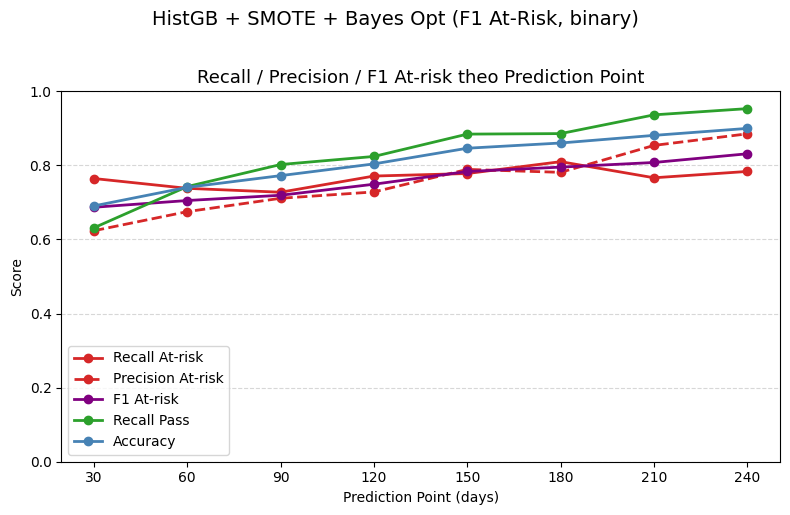

In [9]:
pts = results_df['prediction_point']

fig, ax = plt.subplots(figsize=(8, 5))
for col, label, color, ls in [
    ('recall_at_risk',    'Recall At-risk',    'tab:red',    '-'),
    ('precision_at_risk', 'Precision At-risk', 'tab:red',    '--'),
    ('f1_at_risk',        'F1 At-risk',        'purple',     '-'),
    ('recall_pass',       'Recall Pass',       'tab:green',  '-'),
    ('accuracy',          'Accuracy',          'steelblue',  '-'),
]:
    ax.plot(pts, results_df[col], marker='o', label=label, color=color, linestyle=ls, linewidth=2)
ax.set_title('Recall / Precision / F1 At-risk theo Prediction Point', fontsize=13)
ax.set_xlabel('Prediction Point (days)')
ax.set_ylabel('Score')
ax.set_xticks(SNAPSHOTS)
ax.set_ylim(0, 1)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle('HistGB + SMOTE + Bayes Opt (F1 At-Risk, binary)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---

## Feature Importance — Permutation Importance

Tính permutation importance trên test set cho từng `prediction_point`, dùng F1-score At-risk làm scoring.

In [10]:
from sklearn.inspection import permutation_importance
from sklearn.metrics import make_scorer

f1_at_risk_scorer = make_scorer(f1_score, pos_label=1, zero_division=0)

importance_records = []

for T in SNAPSHOTS:
    _, X_te_raw, _, y_te = get_snapshot_data(T)
    X_te = X_te_raw.fillna(0)

    result = permutation_importance(
        models[T], X_te, y_te,
        scoring=f1_at_risk_scorer,
        n_repeats=10,
        random_state=RANDOM_SEED,
        n_jobs=-1,
    )
    for feat, mean_imp, std_imp in zip(X_te.columns, result.importances_mean, result.importances_std):
        importance_records.append({
            'prediction_point': T,
            'feature': feat,
            'importance_mean': mean_imp,
            'importance_std': std_imp,
        })

importance_df = pd.DataFrame(importance_records)
importance_df

,prediction_point,feature,importance_mean,importance_std
0,30,highest_education,0.015692,0.004414
1,30,disability,0.001287,0.001293
2,30,num_of_prev_attempts,0.004227,0.001475
3,30,studied_credits,0.002990,0.002137
4,30,total_clicks_filled,0.024515,0.001830
...,...,...,...,...
115,240,num_failed_filled,-0.000862,0.001685
116,240,avg_days_early_filled,0.003715,0.001188
117,240,no_submission_despite_due,0.000000,0.000000
118,240,imd_band_filled,-0.000896,0.001005


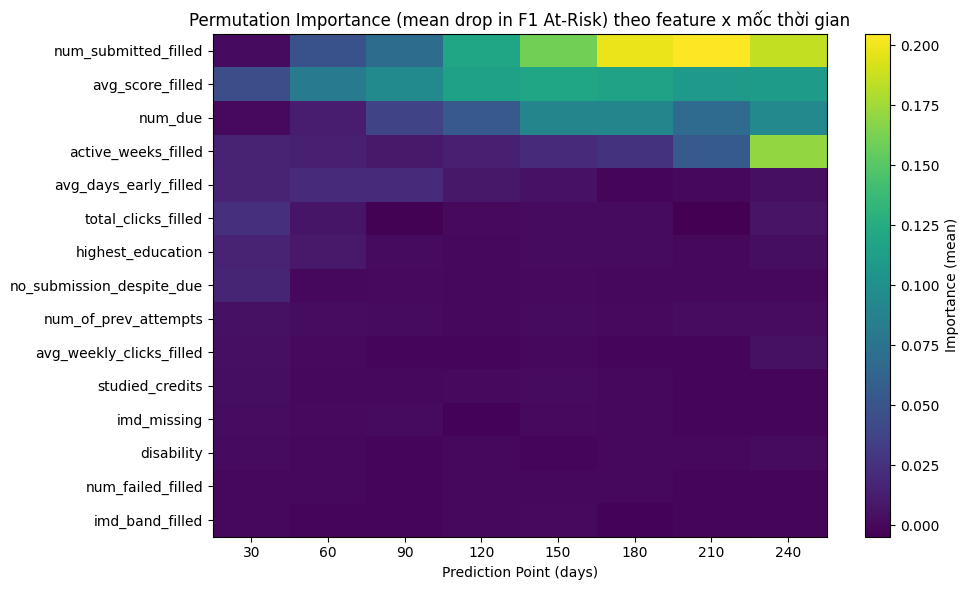


Top feature theo importance trung bình (tất cả mốc):
feature
num_submitted_filled         0.123249
avg_score_filled             0.098645
num_due                      0.056205
active_weeks_filled          0.040526
avg_days_early_filled        0.009171
total_clicks_filled          0.004066
highest_education            0.003880
no_submission_despite_due    0.002170
num_of_prev_attempts         0.001725
avg_weekly_clicks_filled     0.000323
studied_credits              0.000075
imd_missing                 -0.000019
disability                  -0.000081
num_failed_filled           -0.000603
imd_band_filled             -0.001059
dtype: float64


In [11]:
pivot = importance_df.pivot(index='feature', columns='prediction_point', values='importance_mean')
pivot = pivot.loc[pivot.mean(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(pivot.values, aspect='auto', cmap='viridis')
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
ax.set_xlabel('Prediction Point (days)')
ax.set_title('Permutation Importance (mean drop in F1 At-Risk) theo feature x mốc thời gian')
fig.colorbar(im, ax=ax, label='Importance (mean)')
plt.tight_layout()
plt.show()

# Top feature trung bình toàn bộ mốc
top_overall = pivot.mean(axis=1).sort_values(ascending=False)
print('\nTop feature theo importance trung bình (tất cả mốc):')
print(top_overall)